In [ ]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression,RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.decomposition import KernelPCA
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
import category_encoders as ce


from scipy.stats import randint, uniform
from scipy.stats import loguniform


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif
)

from sklearn.svm import SVC



from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    log_loss,
    roc_auc_score,
    f1_score,
    balanced_accuracy_score
)


from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer

from sklearn.pipeline import FunctionTransformer
from sklearn.preprocessing import PowerTransformer, RobustScaler

from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.decomposition import KernelPCA
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import LabelEncoder

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns



from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src import config, utils  
# -------------------------------------------------------


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [49]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

# Flatten target if needed
# Map target to numeric
target = 'Survived'

y_train_numeric = y_train[target]

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

num_classes = len(np.unique(y_train_numeric))

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Number of classes: {num_classes}")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of classes: 2
X_train shape: (891, 13)
X_test shape: (418, 13)


**Special functions for pipline**

In [ ]:


from sklearn.base import BaseEstimator, TransformerMixin


def svd_rounder(x):
    
    x_copy = x.copy()
    for col in [column for column in list(x) if 'SVD' in column]:
        x_copy[col] = (x_copy[col] * 1e18).astype(np.int64)
        
    return x_copy

SVDRounder = FunctionTransformer(svd_rounder)




class FeatureDropper(BaseEstimator, TransformerMixin):
    
    def __init__(self, cols):
        self.cols = cols
        
    def fit(self, x, y):
        return self
    
    def transform(self, x):
        return x.drop(self.cols, axis = 1)

class Categorizer(BaseEstimator, TransformerMixin):
    
    def __init__(self, cols : list):
        self.cols = cols
        
    def fit(self, x, y):
        return self
    
    def transform(self, x):
        return x.astype({cat : 'category' for cat in self.cols})

class Vectorizer(BaseEstimator, TransformerMixin):
    
    def __init__(self, max_features = 1000, cols = ['Surname'], n_components = 3):
        self.max_features = max_features
        self.cols = cols
        self.n_components = n_components
        
    def fit(self, x, y):
        self.vectorizer_dict = {}
        self.decomposer_dict = {}
        
        for col in self.cols:
            self.vectorizer_dict[col] = TfidfVectorizer(max_features = self.max_features).fit(x[col].astype(str), y)
            self.decomposer_dict[col] = TruncatedSVD(random_state = config.SEED, n_components = self.n_components).fit(
                self.vectorizer_dict[col].transform(x[col].astype(str)), y
            )
        
        return self
    
    def transform(self, x):
        vectorized = {}
        
        for col in self.cols:
            vectorized[col] = self.vectorizer_dict[col].transform(x[col].astype(str))
            vectorized[col] = self.decomposer_dict[col].transform(vectorized[col])
        
        vectorized_df = pd.concat([pd.DataFrame(vectorized[col]).rename({
            f'truncatedsvd{i}' : f'{col}SVD{i}' for i in range(self.n_components)
        }, axis = 1) for col in self.cols], axis = 1)
        
        return pd.concat([x.reset_index(drop = True), vectorized_df], axis = 1)


In [ ]:


from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor





# Numeric Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.caps_ = {}

    def fit(self, X, y=None):
        # handle both DataFrame and array
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        for i, col in enumerate(X.columns):
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.caps_[i] = (Q1 - self.factor*IQR, Q3 + self.factor*IQR)  # store by index
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        X = X.copy()
        for i, col in enumerate(X.columns):
            lower, upper = self.caps_[i]
            X[col] = X[col].clip(lower, upper)
        return X.values  # return as array for compatibility


cap_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Optional, only if you have NaNs
    ('cap', OutlierCapper(factor=1.5))
])





# log1p pipeline
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, validate=True)),
    ('cap', OutlierCapper(factor=1.5)),
    ('scaler', MinMaxScaler()),
    ('standard', StandardScaler()) 
])

yj_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('cap', OutlierCapper(factor=1.5)),
    ('scaler', MinMaxScaler()),  # optional if needed
    ('standard', StandardScaler()) 

])

log_cols = []
yj_cols = []
cap_cols = []

other_numeric_cols = [col for col in num_cols if col not in yj_cols]


other_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
     # ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    # ('imputer', IterativeImputer(
    #     estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    #     max_iter=10,
    #     random_state=42
    # )),
    ('scaler', MinMaxScaler()),
    ('standard', StandardScaler())
])



# Categorical Pipeline
target_encode_cols = []  # replace with your chosen cols
ord_cols = []
onehot_cols = [c for c in cat_cols if c not in target_encode_cols]


# Target encoding pipeline
target_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', ce.SumEncoder()) # CatBoostEncoder, MEstimateEncoder
])



# One-hot encoding pipeline
onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=True))
])





ordinal_encoder = OrdinalEncoder(categories=[])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[]))
])






preprocessor = ColumnTransformer(
    transformers=[
        #('log_num', log_pipeline, log_cols),
        # ('yj_num', yj_pipeline, yj_cols),#
        # ('cap_only', cap_pipeline, cap_cols),   # <- new name here
        ('num', other_num_pipeline, num_cols),
        # ('cap_after', cap_pipeline, ['weekly_exercise_min', 'trig_level', 'bp_diastolic']),
        
        
        # Categorical pipelines
        # ('ordinal', ordinal_pipeline, ord_cols),  
        #('target', target_pipeline, target_encode_cols),
        ('onehot', onehot_pipeline, cat_cols) # onehot_cols
    ],
    remainder='passthrough'
)


# Remove near-constant features
variance_filter = VarianceThreshold(threshold=0.01)


# Statistical feature selectio
feature_selector = SelectKBest(
    score_func=f_classif,
    k=300    # tuneable
)


# Full Pipline


def build_pipeline(model):
    """
    Wraps preprocessing + model in a single pipeline
    """
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        #('variance_filter', variance_filter),
        # ('smote', SMOTE(sampling_strategy="not majority", random_state=42)),
        # ('feature_selection', feature_selector),
        # ('poly', PolynomialFeatures(degree=2, include_bias=False)), 
        ('model', model),

    ])
    return pipeline



In [51]:
import joblib
import numpy as np
import os
from sklearn.metrics import roc_auc_score

def save_models_for_stacking(results, X_train, y_train, X_test, y_test, folder="models", version="v1"):
    os.makedirs(folder, exist_ok=True)
    
    for name, res in results.items():
        model = res['best_model']
        
        # -------------------------
        # Compute OOF train predictions
        # -------------------------
        try:
            if hasattr(model, "predict_proba"):
                oof_train = model.predict_proba(X_train)[:, 1] if len(np.unique(y_train)) == 2 else model.predict_proba(X_train)
            else:
                oof_train = model.predict(X_train)
        except:
            oof_train = model.predict(X_train)
        
        # -------------------------
        # Compute test predictions
        # -------------------------
        try:
            if hasattr(model, "predict_proba"):
                pred_test = model.predict_proba(X_test)[:, 1] if len(np.unique(y_train)) == 2 else model.predict_proba(X_test)
            else:
                pred_test = model.predict(X_test)
        except:
            pred_test = model.predict(X_test)
        
        # -------------------------
        # Compute ROC AUC for filename
        # -------------------------
        try:
            if len(np.unique(y_train)) == 2 and hasattr(model, "predict_proba"):
                oof_proba_test = model.predict_proba(X_test)[:, 1]
                auc = roc_auc_score(y_test, oof_proba_test)
                auc_str = f"{auc:.2f}".replace(".", "p")  # 0.71 -> 0p71
            else:
                auc_str = "multi"
        except:
            auc_str = "NA"
        
        # -------------------------
        # Save files
        # -------------------------
        model_path = f"{folder}/{name}_{version}_{auc_str}AUC_optuna.pkl"
        oof_path = f"{folder}/{name}_{version}_{auc_str}AUC_oof_train.npy"
        pred_path = f"{folder}/{name}_{version}_{auc_str}AUC_pred_test.npy"
        
        joblib.dump(model, model_path)
        np.save(oof_path, oof_train)
        np.save(pred_path, pred_test)
        
        print(f"Saved model and predictions for {name} with AUC {auc_str}")


# Optuna

In [117]:
import gc
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.base import clone
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate_optuna_train_metrics(X_train, y_train, model_dict, n_trials=20, cv=5, plot_confusion=True):
    results = {}
    summary_list = []

    feature_names = X_train.columns.tolist()

    for name, cfg in model_dict.items():
        print(f"\n=== Training {name} with Optuna ===")
        pipeline_template = build_pipeline(cfg['model'])
        param_space = cfg['params']

        def objective(trial):
            # Sample hyperparameters from the dictionary
            params = {}
            for k, v in param_space.items():
                if callable(v):
                    params[k.split("__")[-1]] = v(trial)
                else:
                    params[k.split("__")[-1]] = v

            # Clone pipeline and set classifier parameters
            pipeline = clone(pipeline_template)
            pipeline.named_steps['model'].set_params(**params)

            skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
            scores = cross_val_score(
                pipeline, X_train, y_train,
                cv=skf, scoring='neg_log_loss', n_jobs=-1 # neg_log_loss
            )
            return -scores.mean()  # -scores.mean()  for neg_log_loss, -scores.mean() for accuracy (since we want to maximize it)

        # Create study and optimize
        sampler = optuna.samplers.TPESampler(seed=42)  # deterministic sampling

        study = optuna.create_study(direction='minimize', sampler=sampler)
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

        # Fit best model on full training set
        best_pipeline = clone(pipeline_template)
        best_pipeline.named_steps['model'].set_params(**study.best_params)
        best_pipeline.fit(X_train, y_train)


        # ----------------------
        # Evaluate on training set
        # ----------------------
        y_pred = best_pipeline.predict(X_train)
        if hasattr(best_pipeline, "predict_proba"):
            # probability for binary
            if len(np.unique(y_train)) == 2:
                y_proba = best_pipeline.predict_proba(X_train)[:, 1]
            else:
                y_proba = best_pipeline.predict_proba(X_train)
        else:
            y_proba = y_pred  # fallback



        # Predictions
        # y_pred = best_pipeline.predict(X_test)
        # if hasattr(best_pipeline, "predict_proba"):
        #     # take probability of positive class for binary
        #     if len(np.unique(y_train)) == 2:
        #         y_proba = best_pipeline.predict_proba(X_test)[:, 1]
        #     else:
        #         y_proba = best_pipeline.predict_proba(X_test)
        # else:
        #     # fallback: just use 0/1 predictions as "probabilities"
        #     y_proba = y_pred

        # Metrics
        metrics = {
            'accuracy': accuracy_score(y_train, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_train, y_pred),
            'log_loss': log_loss(y_train, y_proba),
            'roc_auc': roc_auc_score(y_train, y_proba),
            'f1_weighted': f1_score(y_train, y_pred, average='binary')
        }

        cm = confusion_matrix(y_train, y_pred, labels=np.unique(y_train))
        results[name] = {
            'best_model': best_pipeline,
            'best_params': study.best_params,
            'metrics': metrics,
            'confusion_matrix': cm
        }

        summary_list.append({
            'Model': name,
            'Accuracy': metrics['accuracy'],
            'Balanced Accuracy': metrics['balanced_accuracy'],
            'Log Loss': metrics['log_loss'],
            'ROC AUC': metrics['roc_auc'],
            'F1 Weighted': metrics['f1_weighted']
        })

        print(f"Best params: {study.best_params}")
        print(f"Metrics: {metrics}")

        if plot_confusion:
            plt.figure(figsize=(6,5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
            plt.title(f'Confusion Matrix: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.show()
        gc.collect()

    summary_df = pd.DataFrame(summary_list).sort_values(by='ROC AUC', ascending=False)
    print("\n=== Summary Table ===")
    display(summary_df)

    return results, summary_df


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models_optuna = {

    # 'ridge': {
    #     'model': RidgeClassifier(),
    #     'params': {
    #         # Only safe params for RidgeClassifier
    #         'model__alpha': lambda trial: trial.suggest_float('alpha', 0.01, 10, log=True),
    #         'model__fit_intercept': lambda trial: trial.suggest_categorical('fit_intercept', [True, False]),
    #         'model__solver': lambda trial: trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'])
    #     }
    # },
    # 'sgd': {
    #     'model': SGDClassifier(max_iter=5000, tol=1e-3, random_state=42),
    #     'params': {
    #         'model__alpha': lambda trial: trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
    #         'model__loss': lambda trial: trial.suggest_categorical('loss', ['hinge', 'log_loss', 'modified_huber']),
    #         'model__penalty': lambda trial: trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    #     }
    # },
       # =========================
    # LDA (solver-aware, SAFE)
    # =========================
    # 'lda': {
    #     'model': LinearDiscriminantAnalysis(),
    #     'params': {
    #         'model__solver': lambda t: t.suggest_categorical(
    #             'solver', ['svd', 'lsqr']
    #         ),
    #         'model__shrinkage': lambda t: (
    #             'auto'
    #             if t.suggest_categorical('solver', ['svd', 'lsqr']) == 'lsqr'
    #             else None
    #         )
    #     }
    # },
    # 'knn': {
    #     'model': KNeighborsClassifier(),
    #     'params': {
    #         'model__n_neighbors': lambda t: t.suggest_int('n_neighbors', 3, 50),
    #         'model__weights': lambda t: t.suggest_categorical(
    #             'weights', ['uniform', 'distance']
    #         ),
    #         'model__p': lambda t: t.suggest_categorical(
    #             'p', [1, 2]  # Manhattan / Euclidean
    #         ),
    #         'model__leaf_size': lambda t: t.suggest_int('leaf_size', 20, 60)
    #     }
    # },
    # 'logistic_lbfgs': {
    #     'model': LogisticRegression(
    #         solver='lbfgs',
    #         max_iter=5000,
    #         n_jobs=-1
    #     ),
    #     'params': {
    #         # Regularization strength
    #         'model__C': lambda trial: trial.suggest_float(
    #             'C', 1e-4, 1e3, log=True
    #         ),

    #         # Whether to include intercept
    #         'model__fit_intercept': lambda trial: trial.suggest_categorical(
    #             'fit_intercept', [True, False]
    #         ),

    #         # Numerical tolerance (affects convergence & speed)
    #         'model__tol': lambda trial: trial.suggest_float(
    #             'tol', 1e-6, 1e-2, log=True
    #         ),

    #         # Warm start can help when data is large
    #         'model__warm_start': lambda trial: trial.suggest_categorical(
    #             'warm_start', [True, False]
    #         ),

    #         # Penalty must be L2 or None
    #         'model__penalty': lambda trial: trial.suggest_categorical(
    #             'penalty', ['l2', None]
    #         ),
    #         'model__class_weight': lambda trial: trial.suggest_categorical(
    #             'class_weight',
    #             [None, 'balanced']
    #         )
    #     }
    # },


    # 'logistic_saga': {
    #     'model': LogisticRegression(
    #         solver='saga',       # 'saga' supports l1, l2, elasticnet and multinomial
    #         max_iter=5000,
    #         n_jobs=-1
    #     ),
    #     'params': {
    #         # Regularization strength (log-scale search)
    #         'model__C': lambda trial: trial.suggest_float('C', 1e-4, 1e3, log=True),

    #         # Whether to fit the intercept
    #         'model__fit_intercept': lambda trial: trial.suggest_categorical('fit_intercept', [True, False]),

    #         # Regularization type: l1, l2, or elasticnet
    #         'model__penalty': lambda trial: trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet']),

    #         # ElasticNet mixing ratio (only used if penalty='elasticnet')
    #         'model__l1_ratio': lambda trial: trial.suggest_float('l1_ratio', 0.0, 1.0),  # ignored if not elasticnet
    #         'model__class_weight': lambda trial: trial.suggest_categorical(
    #             'class_weight',
    #             [None, 'balanced']
    #         )

    #         # Solver is fixed to 'saga' because it supports all penalties and multinomial
    #     }
    # },

    
    # 'GaussianNB': { 'model': GaussianNB(), 'params': {}},

    # 'lin_DiscAnal': {'model': LinearDiscriminantAnalysis(), 'params': {
    #     'model__solver': lambda t: t.suggest_categorical(
    #         'solver', ['svd', 'lsqr']
    #     ),
    #     'model__shrinkage': lambda t: (
    #         'auto'
    #         if t.suggest_categorical('solver', ['svd', 'lsqr']) == 'lsqr'
    #         else None
    #     ),
    #     # 'priors': lambda t: None if t.suggest_categorical('solver', ['svd', 'lsqr'])=='svd' else t.suggest_categorical('priors', [None, [0.3,0.7]]),

        
    # }},


    # 'svm_rbf': {
    #     'model': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    #     'params': {
    #         'model__C': lambda trial: trial.suggest_float('C', 0.1, 100, log=True),
    #         'model__gamma': lambda trial: trial.suggest_float('gamma', 1e-3, 0.1, log=True)
    #     }
    # },


    # 'svm_linear': {
    #     'model': SVC(
    #         kernel='linear',
    #         probability=True,
    #         class_weight='balanced',
    #         random_state=42
    #     ),
    #     'params': {
    #         'model__C': lambda t: t.suggest_float('C', 1e-2, 1e2, log=True)
    #     }
    # },
    # 'svm_poly': {
    #     'model': SVC(
    #         kernel='poly',
    #         probability=True,
    #         class_weight='balanced',
    #         random_state=42
    #     ),
    #     'params': {
    #         'model__C': lambda t: t.suggest_float('C', 1e-2, 1e2, log=True),
    #         'model__degree': lambda t: t.suggest_int('degree', 2),
    #         'model__gamma': lambda t: t.suggest_float('gamma', 1e-3, 1e-1, log=True),
    #         'model__coef0': lambda t: t.suggest_float('coef0', 0.0, 1.0)
    #     }
    # },




    # 'random_forest': {
    #     'model': RandomForestClassifier(
    #         random_state=42,
    #         n_jobs=-1,
    #         class_weight='balanced'
    #     ),
    #     'params': {
    #         'model__n_estimators': lambda trial: trial.suggest_categorical('n_estimators', [100, 300, 500]),
    #         'model__max_depth': lambda trial: trial.suggest_categorical('max_depth', [None, 10, 20]),
    #         'model__max_features': lambda trial: trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    #         'model__min_samples_split': lambda trial: trial.suggest_int('min_samples_split', 2, 10),
    #         'model__min_samples_leaf': lambda trial: trial.suggest_int('min_samples_leaf', 1, 10),
    #         'model__bootstrap': lambda trial: trial.suggest_categorical('bootstrap', [True, False])
    #     }
    # },

    # 'lightgbm': {
    #     'model': LGBMClassifier(
    #         random_state=42,
    #         n_jobs=-1,
    #         class_weight='balanced'
    #     ),
    #     'params': {
    #         'model__n_estimators': lambda trial: trial.suggest_categorical('n_estimators', [100, 300, 500]),
    #         'model__num_leaves': lambda trial: trial.suggest_categorical('num_leaves', [31, 50, 70]),
    #         'model__learning_rate': lambda trial: trial.suggest_categorical('learning_rate', [0.05, 0.1, 0.2]),
    #         'model__subsample': lambda trial: trial.suggest_categorical('subsample', [0.8, 1.0]),
    #         'model__colsample_bytree': lambda trial: trial.suggest_categorical('colsample_bytree', [0.8, 1.0]),
    #         'model__min_child_samples': lambda trial: trial.suggest_int('min_child_samples', 5, 30),
    #         'model__reg_alpha': lambda trial: trial.suggest_float('reg_alpha', 0.0, 1.0),
    #         'model__reg_lambda': lambda trial: trial.suggest_float('reg_lambda', 0.0, 1.0)
    #     }
    # },
    # 'xgboost': {
    #     'model': XGBClassifier(
    #         objective='binary:logistic',  # binary classification
    #         eval_metric='logloss',
    #         use_label_encoder=False,
    #         n_jobs=-1,
    #         random_state=42
    #     ),
    #     'params': {
    #         'model__n_estimators': lambda trial: trial.suggest_categorical('n_estimators', [100, 300, 500]),
    #         'model__max_depth': lambda trial: trial.suggest_int('max_depth', 3, 12),
    #         'model__learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
    #         'model__subsample': lambda trial: trial.suggest_float('subsample', 0.5, 1.0),
    #         'model__colsample_bytree': lambda trial: trial.suggest_float('colsample_bytree', 0.5, 1.0),
    #         'model__gamma': lambda trial: trial.suggest_float('gamma', 0.0, 5.0),
    #         'model__reg_alpha': lambda trial: trial.suggest_float('reg_alpha', 0.0, 1.0),
    #         'model__reg_lambda': lambda trial: trial.suggest_float('reg_lambda', 0.0, 1.0),
    #         'model__min_child_weight': lambda trial: trial.suggest_int('min_child_weight', 1, 10)
    #     }
    # },

    'gradient_boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'model__n_estimators': lambda trial: trial.suggest_int('n_estimators', 100, 1000),
            'model__learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
            'model__max_depth': lambda trial: trial.suggest_categorical('max_depth', [3, 5, 7, 10]),
            'model__subsample': lambda trial: trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
            'model__max_features': lambda trial: trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        }
    },
    # 'extratrees': {
    #     'model': ExtraTreesClassifier(random_state=42),
    #     'params': {
    #         'model__n_estimators': lambda trial: trial.suggest_int('n_estimators', 100, 1000),
    #         'model__max_depth': lambda trial: trial.suggest_int('max_depth', 5, 40),
    #         'model__min_samples_split': lambda trial: trial.suggest_int('min_samples_split', 2, 20),
    #         'model__min_samples_leaf': lambda trial: trial.suggest_int('min_samples_leaf', 1, 10),
    #         'model__max_features': lambda trial: trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    #         'model__bootstrap': lambda trial: trial.suggest_categorical('bootstrap', [True, False])
    #     }
    # },
    # 'adaboost': {
    #     'model': AdaBoostClassifier(random_state=42),
    #     'params': {
    #         'model__n_estimators': lambda trial: trial.suggest_int('n_estimators', 50, 500),
    #         'model__learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
    #         'model__algorithm': lambda trial: trial.suggest_categorical('algorithm', ['SAMME', 'SAMME.R'])

    
    #     }
    # }

    # 'mlp': MLPClassifier(random_state=self.random_state, max_iter=1000)



}




In [123]:
results, summary_df = train_and_evaluate_optuna_train_metrics(X_train, y_train, models_optuna, n_trials=20, cv=3, plot_confusion=False)


[I 2026-02-09 23:18:21,736] A new study created in memory with name: no-name-0b93eb46-4f88-4ec5-a208-06a8831c9427



=== Training logistic_lbfgs with Optuna ===


  0%|          | 0/20 [00:00<?, ?it/s]

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1186: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1186: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/li

[I 2026-02-09 23:18:21,809] Trial 0 finished with value: 0.4565886451778794 and parameters: {'C': 0.041858227295469716, 'fit_intercept': True, 'tol': 0.0002481040974867811, 'warm_start': True, 'penalty': None, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.4565886451778794.
[I 2026-02-09 23:18:21,873] Trial 1 finished with value: 0.44064152099580656 and parameters: {'C': 0.000139345022513376, 'fit_intercept': True, 'tol': 7.068974950624607e-06, 'warm_start': False, 'penalty': None, 'class_weight': None}. Best is trial 1 with value: 0.44064152099580656.
[I 2026-02-09 23:18:21,935] Trial 2 finished with value: 0.46970173347563743 and parameters: {'C': 1.918537370384187, 'fit_intercept': False, 'tol': 2.9204338471814107e-05, 'warm_start': False, 'penalty': None, 'class_weight': None}. Best is trial 1 with value: 0.44064152099580656.


...

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[I 2026-02-09 23:18:42,025] Trial 18 finished with value: 0.603625670932047 and parameters: {'n_estimators': 372, 'learning_rate': 0.01559101508673201, 'max_depth': 10, 'subsample': 0.6, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.4086570302238211.


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[I 2026-02-09 23:18:42,239] Trial 19 finished with value: 0.41568048561955484 and parameters: {'n_estimators': 205, 'learning_rate': 0.010609114900209595, 'max_depth': 5, 'subsample': 0.6, 'max_features': 'log2'}. Best is trial 16 with value: 0.4086570302238211.
Best params: {'n_estimators': 427, 'learning_rate': 0.016545289805703006, 'max_depth': 3, 'subsample': 0.6, 'max_features': 'sqrt'}
Metrics: {'accuracy': 0.8653198653198653, 'balanced_accuracy': 0.8504697536190202, 'log_loss': 0.3509933691708634, 'roc_auc': 0.9111595777543433, 'f1_weighted': 0.817629179331307}

=== Summary Table ===


,Model,Accuracy,Balanced Accuracy,Log Loss,ROC AUC,F1 Weighted
2,gradient_boosting,0.865320,0.850470,0.350993,0.911160,0.817629
1,logistic_saga,0.818182,0.804501,0.427276,0.865936,0.758929
0,logistic_lbfgs,0.818182,0.803950,0.427502,0.865723,0.758209


In [ ]:
best_model_name = summary_df.iloc[0]['Model']  # summary_df is already sorted by ROC AUC

best_pipeline = results[best_model_name]['best_model']


# Predict on test set
if hasattr(best_pipeline, "predict_proba") and len(np.unique(y_train)) == 2:
    pred_test_class = (best_pipeline.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
else:
    pred_test_class = best_pipeline.predict(X_test)

# Prepare submission
submission = pd.DataFrame({
    "PassengerId": test_ids,  # make sure you saved this earlier
    "Survived": pred_test_class
})
# Prepare submission
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": pred_test_class
})

submission.to_csv(f"submission/linModel_{best_model_name.lower()}_optuna.csv", index=False)
print(f"Submission saved for best model: {best_model_name}")

Submission saved for best model: random_forest


# For Stacking

In [40]:
import os
import gc
import time
import numpy as np
import pandas as pd
import optuna
from sklearn.base import clone
from sklearn.metrics import log_loss, accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def train_stackable_models_with_folds(X_train, y_train, X_test, models_optuna, folds, n_trials=20, plot_confusion=True):
    """
    Train multiple models using Optuna with precomputed folds.
    Returns OOF predictions, test predictions, and metrics for stacking.
    """
    results = {}
    oof_preds_dict = {}
    test_preds_dict = {}

    n_classes = len(np.unique(y_train))

    for name, cfg in models_optuna.items():
        print(f"\n=== Training {name} with Optuna ===")

        pipeline_template = build_pipeline(cfg['model'])  # user-defined pipeline builder
        param_space = cfg['params']

        # Prepare OOF and test arrays
        oof_preds = np.zeros((X_train.shape[0], n_classes))
        test_preds = np.zeros((X_test.shape[0], n_classes))

        # ------------------------------
        # Optuna objective
        # ------------------------------
        def objective(trial):
            params = {}
            for k, v in param_space.items():
                if callable(v):
                    params[k.split("__")[-1]] = v(trial)
                else:
                    params[k.split("__")[-1]] = v

            fold_scores = []
            for fold_num, (train_idx, val_idx) in enumerate(folds):
                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

                pipeline = clone(pipeline_template)
                pipeline.named_steps['model'].set_params(**params)
                pipeline.fit(X_tr, y_tr)

                if hasattr(pipeline, "predict_proba"):
                    if n_classes == 2:
                        y_val_pred = pipeline.predict_proba(X_val)[:, 1]
                    else:
                        y_val_pred = pipeline.predict_proba(X_val)
                else:
                    y_val_pred = pipeline.predict(X_val)
                    if n_classes > 2:
                        # One-hot encode predictions
                        y_val_pred = np.eye(n_classes)[y_val_pred]

                fold_scores.append(log_loss(y_val, y_val_pred))

                trial.report(fold_scores[-1], step=fold_num)
                if trial.should_prune():
                    raise optuna.TrialPruned()

                del X_tr, X_val, y_tr, y_val, pipeline, y_val_pred
                gc.collect()

            return np.mean(fold_scores)

        # ------------------------------
        # Run Optuna study
        # ------------------------------
        sampler = optuna.samplers.TPESampler(n_startup_trials=5, multivariate=True)
        pruner = optuna.pruners.SuccessiveHalvingPruner()
        study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

        print(f"Best params for {name}: {study.best_params}")

        # ------------------------------
        # Train final model with OOF + test preds
        # ------------------------------
        best_pipeline_template = clone(pipeline_template)
        best_pipeline_template.named_steps['model'].set_params(**study.best_params)

        for fold_num, (train_idx, val_idx) in enumerate(folds):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            pipeline = clone(best_pipeline_template)
            pipeline.fit(X_tr, y_tr)

            # OOF predictions
            if hasattr(pipeline, "predict_proba"):
                if n_classes == 2:
                    oof_preds[val_idx, 1] = pipeline.predict_proba(X_val)[:, 1]
                else:
                    oof_preds[val_idx] = pipeline.predict_proba(X_val)
            else:
                pred = pipeline.predict(X_val)
                if n_classes == 2:
                    oof_preds[val_idx, 1] = pred
                else:
                    oof_preds[val_idx] = np.eye(n_classes)[pred]

            # Test predictions (average across folds)
            if hasattr(pipeline, "predict_proba"):
                if n_classes == 2:
                    test_preds[:, 1] += pipeline.predict_proba(X_test)[:, 1] / len(folds)
                else:
                    test_preds += pipeline.predict_proba(X_test) / len(folds)
            else:
                pred_test = pipeline.predict(X_test)
                if n_classes == 2:
                    test_preds[:, 1] += pred_test / len(folds)
                else:
                    test_preds += np.eye(n_classes)[pred_test] / len(folds)

            print(f"Fold {fold_num} done for {name}")
            del X_tr, X_val, y_tr, y_val, pipeline
            gc.collect()

        # ------------------------------
        # Metrics on training set
        # ------------------------------
        if n_classes == 2:
            y_pred_class = (oof_preds[:, 1] >= 0.5).astype(int)
            y_proba = oof_preds[:, 1]
        else:
            y_pred_class = np.argmax(oof_preds, axis=1)
            y_proba = oof_preds

        metrics = {
            'accuracy': accuracy_score(y_train, y_pred_class),
            'balanced_accuracy': balanced_accuracy_score(y_train, y_pred_class),
            'log_loss': log_loss(y_train, y_proba),
            'roc_auc': roc_auc_score(y_train, y_proba, multi_class='ovr'),
            'f1_weighted': f1_score(y_train, y_pred_class, average='weighted')
        }


        cm = confusion_matrix(y_train, y_pred_class)
        results[name] = {
            'best_params': study.best_params,
            'metrics': metrics,
            'confusion_matrix': cm
        }

        oof_preds_dict[name] = oof_preds
        test_preds_dict[name] = test_preds

        if plot_confusion:
            plt.figure(figsize=(6,5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.show()

        gc.collect()

    return results, oof_preds_dict, test_preds_dict


[I 2026-02-09 20:50:27,620] A new study created in memory with name: no-name-426536b9-d214-4c4c-a117-21ac73e32f17



=== Training sgd with Optuna ===


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-09 20:50:30,133] Trial 0 finished with value: 8.362538722467399 and parameters: {'alpha': 7.064440988228204e-05, 'loss': 'modified_huber', 'penalty': 'elasticnet'}. Best is trial 0 with value: 8.362538722467399.
[I 2026-02-09 20:50:32,189] Trial 1 finished with value: 0.957160411220299 and parameters: {'alpha': 0.006543371599157715, 'loss': 'modified_huber', 'penalty': 'l1'}. Best is trial 1 with value: 0.957160411220299.
[I 2026-02-09 20:50:34,293] Trial 2 finished with value: 0.43946244371181387 and parameters: {'alpha': 0.004505343745544288, 'loss': 'log_loss', 'penalty': 'elasticnet'}. Best is trial 2 with value: 0.43946244371181387.
[I 2026-02-09 20:50:34,537] Trial 3 pruned. 
[I 2026-02-09 20:50:34,763] Trial 4 pruned. 
[I 2026-02-09 20:50:34,987] Trial 5 pruned. 
[I 2026-02-09 20:50:35,221] Trial 6 pruned. 
[I 2026-02-09 20:50:35,475] Trial 7 pruned. 
[I 2026-02-09 20:50:35,720] Trial 8 pruned. 
[I 2026-02-09 20:50:35,960] Trial 9 pruned. 
[I 2026-02-09 20:50:36,215] 

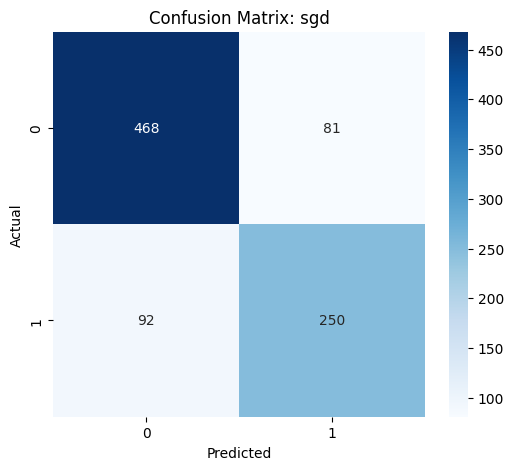

[I 2026-02-09 20:50:42,920] A new study created in memory with name: no-name-b477df43-adfc-4f11-9915-c5825b73fd75



=== Training lda with Optuna ===


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-09 20:50:44,679] Trial 0 finished with value: 0.454752549802512 and parameters: {'solver': 'svd'}. Best is trial 0 with value: 0.454752549802512.
[I 2026-02-09 20:50:45,679] Trial 1 finished with value: 0.45389583779702186 and parameters: {'solver': 'lsqr'}. Best is trial 1 with value: 0.45389583779702186.
[I 2026-02-09 20:50:46,757] Trial 2 finished with value: 0.45389583779702186 and parameters: {'solver': 'lsqr'}. Best is trial 1 with value: 0.45389583779702186.
[I 2026-02-09 20:50:47,054] Trial 3 pruned. 
[I 2026-02-09 20:50:47,431] Trial 4 pruned. 
[I 2026-02-09 20:50:48,915] Trial 5 finished with value: 0.45389583779702186 and parameters: {'solver': 'lsqr'}. Best is trial 1 with value: 0.45389583779702186.
[I 2026-02-09 20:50:50,071] Trial 6 finished with value: 0.45389583779702186 and parameters: {'solver': 'lsqr'}. Best is trial 1 with value: 0.45389583779702186.
[I 2026-02-09 20:50:51,274] Trial 7 finished with value: 0.45389583779702186 and parameters: {'solver': '

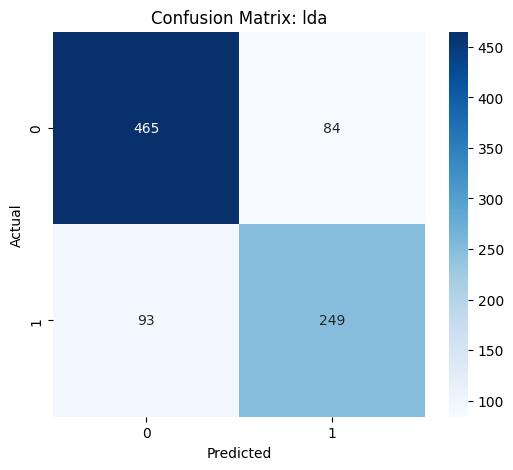

[I 2026-02-09 20:51:02,949] A new study created in memory with name: no-name-af4a65ed-4060-49c2-813f-04a4feb75482



=== Training logistic_lbfgs with Optuna ===


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-09 20:51:07,614] Trial 0 finished with value: 0.4380840446104508 and parameters: {'C': 0.49373999506698196, 'fit_intercept': True, 'tol': 3.960269435170163e-06, 'warm_start': False, 'penalty': 'l2', 'class_weight': None}. Best is trial 0 with value: 0.4380840446104508.
[I 2026-02-09 20:51:11,487] Trial 1 finished with value: 0.45619746816465623 and parameters: {'C': 12.229277092714822, 'fit_intercept': True, 'tol': 0.003605979577377989, 'warm_start': True, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.4380840446104508.
[I 2026-02-09 20:51:13,003] Trial 2 pruned. 
[I 2026-02-09 20:51:14,392] Trial 3 pruned. 
[I 2026-02-09 20:51:15,788] Trial 4 pruned. 
[I 2026-02-09 20:51:16,830] Trial 5 finished with value: 0.43895794217583656 and parameters: {'C': 7.020514277630388, 'fit_intercept': True, 'tol': 2.401734186055589e-05, 'warm_start': False, 'penalty': 'l2', 'class_weight': None}. Best is trial 0 with value: 0.4380840446104508.
[I 2026-02-09 20:51

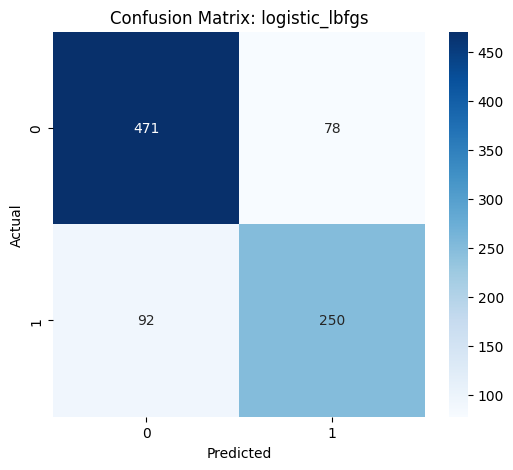

[I 2026-02-09 20:51:24,395] A new study created in memory with name: no-name-e7d6b762-920e-4a74-abbd-815f2de20d9e



=== Training random_forest with Optuna ===


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-09 20:51:25,637] Trial 0 finished with value: 1.4297373823812654 and parameters: {'n_estimators': 300, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}. Best is trial 0 with value: 1.4297373823812654.
[I 2026-02-09 20:51:26,670] Trial 1 finished with value: 0.4372202991694144 and parameters: {'n_estimators': 100, 'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 3, 'min_samples_leaf': 7, 'bootstrap': False}. Best is trial 1 with value: 0.4372202991694144.
[I 2026-02-09 20:51:26,901] Trial 2 pruned. 
[I 2026-02-09 20:51:27,157] Trial 3 pruned. 
[I 2026-02-09 20:51:28,137] Trial 4 finished with value: 0.43629935070696463 and parameters: {'n_estimators': 100, 'max_depth': None, 'max_features': 'log2', 'min_samples_split': 7, 'min_samples_leaf': 9, 'bootstrap': False}. Best is trial 4 with value: 0.43629935070696463.
[I 2026-02-09 20:51:28,381] Trial 5 pruned. 
[I 2026-02-09 20:51:28,626] Trial 6 pruned. 
[I 

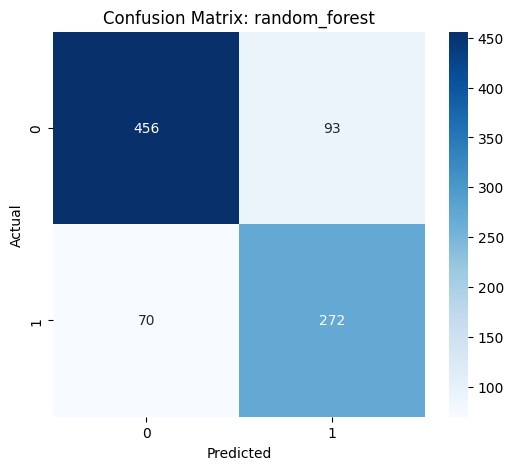

In [41]:

folds_path = './fold_indices.npy'  # adjust path if needed
folds = np.load(folds_path, allow_pickle=True)

results, oof_preds_dict, test_preds_dict = train_stackable_models_with_folds(
    X_train, y_train, X_test, models_optuna, folds, n_trials=20
)


In [47]:
for name in oof_preds_dict.keys():
    # Save probability of positive class (class 1)
    np.save(f"oof_preds/{name}_lin_mo_optuna_oof.npy", oof_preds_dict[name][:, 1])
    np.save(f"test_preds/{name}_lin_mo_optuna_test.npy", test_preds_dict[name][:, 1])

    print(f"Saved OOF and test predictions for {name}")


Saved OOF and test predictions for sgd
Saved OOF and test predictions for lda
Saved OOF and test predictions for logistic_lbfgs
Saved OOF and test predictions for random_forest


Then, to create a Kaggle submission from one model:

In [ ]:
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": (test_preds["rf"] >= 0.5).astype(int)
})
submission.to_csv("submission/rf_submission.csv", index=False)


In [203]:
save_models_for_stacking(
    results, 
    X_train, y_train_enc, 
    X_test, y_test_enc, 
    folder="models", 
    version="v2"
)


Saved model and predictions for sgd with AUC 0p69
Saved model and predictions for lda with AUC 0p71
Saved model and predictions for knn with AUC 0p68
Saved model and predictions for logistic_lbfgs with AUC 0p71
Saved model and predictions for logistic_saga with AUC 0p71
Saved model and predictions for random_forest with AUC 0p70
Saved model and predictions for lightgbm with AUC 0p71
Saved model and predictions for xgboost with AUC 0p71
Saved model and predictions for gradient_boosting with AUC 0p71
Saved model and predictions for adaboost with AUC 0p70


In [204]:
import os
import joblib
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

folder = "models"

# Automatically get all OOF train files and test prediction files
oof_train_files = sorted([f for f in os.listdir(folder) if f.endswith("_oof_train.npy")])
pred_test_files = sorted([f for f in os.listdir(folder) if f.endswith("_pred_test.npy")])

# Make sure files match
assert len(oof_train_files) == len(pred_test_files), "Mismatch in OOF and test files!"

# Load all predictions
oof_train_list = []
pred_test_list = []

for oof_file, test_file in zip(oof_train_files, pred_test_files):
    oof_train = np.load(os.path.join(folder, oof_file))
    pred_test = np.load(os.path.join(folder, test_file))
    
    # Make sure shapes are correct
    oof_train_list.append(oof_train.reshape(-1, 1))
    pred_test_list.append(pred_test.reshape(-1, 1))

# Stack horizontally for meta-model
X_stack_train = np.hstack(oof_train_list)
X_stack_test = np.hstack(pred_test_list)

print("Stacked train shape:", X_stack_train.shape)
print("Stacked test shape:", X_stack_test.shape)

# Train meta-model (Logistic Regression)
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(X_stack_train, y_train_enc)  # use your original labels

# Predict test
stack_pred = meta_model.predict_proba(X_stack_test)[:, 1]

# Evaluate
roc = roc_auc_score(y_test_enc, stack_pred)
print("Stacking ROC AUC:", roc)


Stacked train shape: (18964, 27)
Stacked test shape: (4742, 27)
Stacking ROC AUC: 0.6929376279497581


In [205]:
import os
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

folder = "models"

# Get all test prediction files (works even with AUC/version in filename)
pred_test_files = sorted([f for f in os.listdir(folder) if f.endswith("_pred_test.npy")])

pred_test_list = []

for file in pred_test_files:
    pred_test_path = os.path.join(folder, file)
    pred_test = np.load(pred_test_path)
    pred_test_list.append(pred_test.reshape(-1, 1))

# Blend predictions by averaging
X_blend_test = np.hstack(pred_test_list)
blended_pred_proba = X_blend_test.mean(axis=1)  # simple average

# Convert to class labels for binary classification
blended_pred_class = (blended_pred_proba > 0.5).astype(int)

# Evaluate
roc = roc_auc_score(y_test_enc, blended_pred_proba)
acc = accuracy_score(y_test_enc, blended_pred_class)
f1 = f1_score(y_test_enc, blended_pred_class)

print(f"Blending ROC AUC: {roc:.4f}")
print(f"Blending Accuracy: {acc:.4f}")
print(f"Blending F1 Score: {f1:.4f}")


Blending ROC AUC: 0.7126
Blending Accuracy: 0.6755
Blending F1 Score: 0.7518


# Without Optuna

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import CategoricalNB, ComplementNB
from sklearn.neighbors import NearestCentroid, RadiusNeighborsClassifier
from sklearn.svm import SVC, NuSVC
from scipy.stats import loguniform
from sklearn.decomposition import PCA


base_models = {
    'logistic': {
        'model': LogisticRegression(
            solver='lbfgs',          # fastest + stable
            max_iter=1000,
            n_jobs=-1,
            class_weight='balanced'
        ),
        'params': {
            'model__C': [0.1, 1, 10],     # MOST important
            'model__fit_intercept': [True]
        }
    },
    'sgd': {
        'model': SGDClassifier(
            max_iter=2000,
            tol=1e-3,
            random_state=42
        ),
        'params': {
            'model__loss': ['log_loss', 'hinge'],
            'model__alpha': [1e-4, 1e-3, 1e-2],   # regularization strength
            'model__penalty': ['l2']
        }
    },
    'svm_rbf': {
        'model': SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'params': {
            'model__C': [1, 10],
            'model__gamma': ['scale', 0.01]
        }
    },
    'knn': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [5, 15, 30],
            'model__weights': ['uniform', 'distance']
        }
    },
    # 'random_forest': {
    #     'model': RandomForestClassifier(
    #         random_state=42,
    #         n_jobs=-1,
    #         class_weight='balanced'
    #     ),
    #     'params': {
    #         'model__n_estimators': [100, 300],
    #         'model__max_depth': [None, 10],
    #         'model__max_features': ['sqrt']
    #     }
    # },
    # # 🌲 LightGBM
    # 'lightgbm': {
    #     'model': LGBMClassifier(
    #         random_state=42,
    #         n_jobs=-1,
    #         class_weight='balanced'
    #     ),
    #     'params': {
    #         'model__n_estimators': [100, 300, 500],
    #         'model__num_leaves': [31, 50, 70],
    #         'model__learning_rate': [0.05, 0.1, 0.2],
    #         'model__subsample': [0.8, 1.0],
    #         'model__colsample_bytree': [0.8, 1.0]
    #     }
    # },


}

# Dictionary of models + param grids
models = {
    'logistic': {
        'model': LogisticRegression(
            solver='lbfgs',#saga
            max_iter=5000,
            n_jobs=-1,
            class_weight='balanced'
        ),
        'params': {
            'model__C': loguniform(1e-3, 1e3),
            'model__penalty': ['l1', 'l2', 'elasticnet'],
            'model__fit_intercept': [True, False],
            'model__l1_ratio': [0, 0.5, 1]
        }
    },


        # 12️⃣ PCA + Logistic Regression pipeline
    # 'pca_logistic': {
    #     'model': Pipeline([
    #         ('pca', PCA()),
    #         ('logistic', LogisticRegression(
    #             multi_class='multinomial',
    #             solver='saga',
    #             max_iter=5000,
    #             n_jobs=-1
    #         ))
    #     ]),
    #     'params': {
    #         'pca__n_components': [5, 10, 15, 20],
    #         'logistic__C': loguniform(0.1, 100),
    #         'logistic__penalty': ['l1', 'l2', 'elasticnet'],
    #         'logistic__l1_ratio': [0, 0.5, 1]
    #     }
    # },
    'ridge': {
        'model': RidgeClassifier(),
        'params': {
            'model__alpha': loguniform(0.01, 10)
        }
    },


    'sgd': {
        'model': SGDClassifier(max_iter=5000, tol=1e-3, random_state=42),
        'params': {
            'model__loss': ['hinge', 'log', 'modified_huber'],
            'model__penalty': ['l2', 'l1', 'elasticnet'],
            'model__alpha': loguniform(1e-5, 1e-1)
        }
    },

       # --- Naive Bayes ---
    
    #----------------
    # Error
    #---------------
    # 'gaussian_nb': {
    #     'model': GaussianNB(),
    #     'params': {}
    # },

    # 'multinomial_nb': {
    #     'model': MultinomialNB(),
    #     'params': {'model__alpha':[0.1,0.5,1.0]}
    # },

    # 'bernoulli_nb': {
    #     'model': BernoulliNB(),
    #     'params': {'model__alpha':[0.1,0.5,1.0]}
    # },


    # 'passive_aggressive': {
    #     'model': PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    #     'params': {'model__C': loguniform(0.1,10)
    #     }
    # },
    
    # -----------------
    # Error
    # -----------------
    # 'nusvc': {
    #     'model': NuSVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    #     'params': {'model__nu':[0.2,0.4,0.6,0.8], 'model__gamma': loguniform(1e-3,0.1)}
    # },

    # 'complement_nb': {'model': ComplementNB(), 'params': {'model__alpha':[0.1,0.5,1.0]}},
    # -----------------
    # Error
    # -----------------
    # 'categorical_nb': {'model': CategoricalNB(), 'params': {'model__alpha':[0.1,0.5,1.0]}},


    'svm_rbf': {
        'model': SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'params': {
            # 'model__C': loguniform(1e-2, 1e3), for wider range
            # 'model_gamma': loguniform(1e-4, 10), for wider range
            "model__C": loguniform(0.1, 100),
            "model__gamma": loguniform(1e-3, 0.1)
        }
    },

#------------------
# This was good model
#------------------

    'svm_poly': {
        'model': SVC(
            kernel='poly',
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'params': {
            "model__C": loguniform(0.1, 100),          # regularization
            "model__degree": [2],             # polynomial degree
            "model__gamma": loguniform(1e-3, 0.1),     # kernel width
            "model__coef0": [0, 0.1, 0.5, 1]           # independent term in poly kernel
        }
    },


#------------------
#------------------
    # Too Much Time
    'svm_linear': {
        'model': SVC(
            kernel='linear',
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'params': {
            'model__C': loguniform(0.1, 100) # loguniform(1e-2, 1e2)
        }
    },

    # -----------------
    # Error
    # -----------------
    # 'svm_calibrated': {
    #     'model': CalibratedClassifierCV(estimator=SVC(probability=True, kernel='rbf', random_state=42)),
    #     'params': {
    #         'base_estimator__C': loguniform(0.1,100), 
    #         'base_estimator__gamma': loguniform(1e-3,0.1)
    #     }
    # },

    'knn': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': randint(3, 50),        # number of neighbors
            'model__weights': ['uniform', 'distance'],   # weighting function
            'model__p': [1, 2]                           # 1 = Manhattan, 2 = Euclidean
        },
    },

    # -----------------
    # Error
    # -----------------
    # 'radius_neighbors': {
    #     'model': RadiusNeighborsClassifier(),
    #     'params': {
    #         'model__radius':[0.5,1.0,2.0]
    #     }
    # },
    
    # 'nearest_centroid': {
    #     'model': NearestCentroid(),
    #     'params': {}
    # },


    'lda': {
        'model': LinearDiscriminantAnalysis(),
        'params': {
            'model__solver': ['svd', 'lsqr', 'eigen'],           # solver choices
            'model__shrinkage': [None, 'auto', 0.1, 0.5, 0.9]      # only used with lsqr/eigen
        }
    },
#------------------
# Error
#------------------

    # 'kpca_lda': {   # <-- new pipeline entry
    #     'model': Pipeline([
    #         ('kpca', KernelPCA(random_state=42, fit_inverse_transform=False)),
    #         ('lda', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    #     ]),
    #     'params': {
    #         'kpca__n_components': [5, 10, 15, 30],
    #         'kpca__kernel': ['rbf', 'poly'],
    #         'kpca__gamma': [0.01, 0.05, 0.1],
    #         'kpca__degree': [2, 3],           # only used for poly
    #         'lda__shrinkage': ['auto', 0.1, 0.5]
    #     }
    # },
    

    # -----------------
    # Error
    # -----------------
    # 'qda': {
    #     'model': QuadraticDiscriminantAnalysis(),
    #     'params': {
    #         'model__reg_param': [0.0, 0.1, 0.5]  # regularization for QDA
    #     }
    # },






    # # # 8️⃣ Random Forest
    # 'random_forest': {
    #     'model': RandomForestClassifier(
    #         random_state=42,
    #         n_jobs=-1
    #     ),
    #     'params': {
    #         'model__n_estimators': randint(100, 1000),
    #         'model__max_depth': [None, 5, 10, 20],
    #         'model__min_samples_split': [2, 5, 10],
    #         'model__min_samples_leaf': [1, 2, 4],
    #         'model__max_features': ['sqrt', 'log2', None]
    #     }
    # },

    # # # 9️⃣ Gradient Boosting
    'gradient_boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'model__n_estimators': randint(100, 1000),
            'model__learning_rate': loguniform(0.01, 0.5),
            'model__max_depth': [3, 5, 7, 10],
            'model__subsample': [0.6, 0.8, 1.0],
            'model__max_features': ['sqrt', 'log2', None]
        }
    },

    # 🔟 AdaBoost
    'adaboost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'model__n_estimators': randint(50, 500),
            'model__learning_rate': loguniform(0.01, 1.0)
        }
    },



    


}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, log_loss,
    roc_auc_score, f1_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt




def train_and_evaluate(X_train, y_train, X_test, y_test, model_dict, n_iter=20, cv=5, plot_confusion=True, plot_importance=True):
    results = {}
    summary_list = []

    feature_names = X_train.columns.tolist()  # get column names for importance

    for name, cfg in model_dict.items():
        print(f"\n=== Training {name} ===")
        pipeline = build_pipeline(cfg['model'])

        search = RandomizedSearchCV(
            pipeline,
            param_distributions=cfg['params'],
            n_iter=n_iter,
            cv=cv,
            scoring='neg_log_loss',
            verbose=1,
            n_jobs=-1,
            random_state=42,
            refit=True
        )

        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)

        # Robust probability handling
        if hasattr(best_model, "predict_proba"):
            # take probability of positive class
            if len(np.unique(y_train)) == 2:
                y_proba = best_model.predict_proba(X_test)[:, 1]  # shape (n_samples,)
            else:
                y_proba = best_model.predict_proba(X_test)         # multi-class ok
        else:
            # fallback: use 0/1 predictions as "probabilities"
            y_proba = y_pred

        # Metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'log_loss': log_loss(y_test, y_proba),
            'roc_auc': roc_auc_score(y_test, y_proba),
            'f1_weighted': f1_score(y_test, y_pred, average='binary')
        }

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        results[name] = {
            'best_model': best_model,
            'best_params': search.best_params_,
            'cv_score': search.best_score_,
            'metrics': metrics,
            'confusion_matrix': cm
        }

        # Add summary row
        summary_list.append({
            'Model': name,
            'CV Score': search.best_score_,
            'Accuracy': metrics['accuracy'],
            'Balanced Accuracy': metrics['balanced_accuracy'],
            'Log Loss': metrics['log_loss'],
            'ROC AUC': metrics['roc_auc'],
            'F1 Weighted': metrics['f1_weighted']
        })

        print(f"Best params: {search.best_params_}")
        print(f"Metrics: {metrics}")

        # Plot confusion matrix
        if plot_confusion:
            plt.figure(figsize=(6,5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
            plt.title(f'Confusion Matrix: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.show()




    # Summary table
    summary_df = pd.DataFrame(summary_list)
    summary_df = summary_df.sort_values(by='ROC AUC', ascending=False)
    print("\n=== Summary Table ===")
    display(summary_df)

    return results, summary_df



=== Training logistic ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__C': 0.035700959600309494, 'model__fit_intercept': False, 'model__l1_ratio': 0.5, 'model__penalty': 'l2'}
Metrics: {'accuracy': 0.6005904681568959, 'balanced_accuracy': 0.6185795928943656, 'log_loss': 0.6430590638650141, 'roc_auc': 0.670849578817051, 'f1_weighted': 0.6059420319102732}


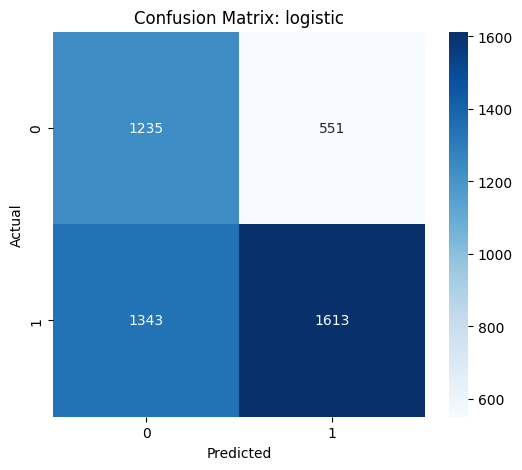


=== Training ridge ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__alpha': 0.13292918943162169}
Metrics: {'accuracy': 0.6488823281315901, 'balanced_accuracy': 0.5731005096018196, 'log_loss': 12.65556366361874, 'roc_auc': 0.5731005096018196, 'f1_weighted': 0.609092972474779}


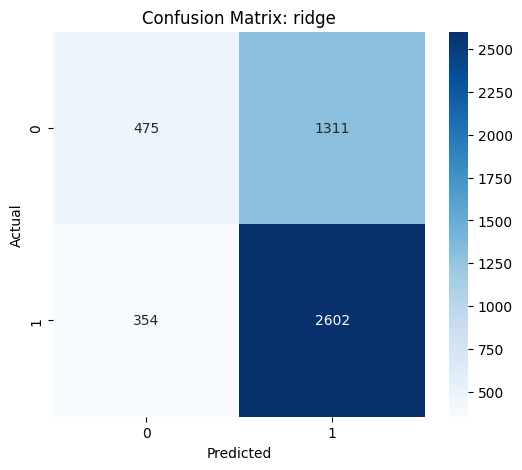


=== Training sgd ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__alpha': 0.0027541439213320295, 'model__loss': 'modified_huber', 'model__penalty': 'elasticnet'}
Metrics: {'accuracy': 0.6442429354702657, 'balanced_accuracy': 0.5687144184129457, 'log_loss': 0.720043701475328, 'roc_auc': 0.6694622094565005, 'f1_weighted': 0.6046302523934798}


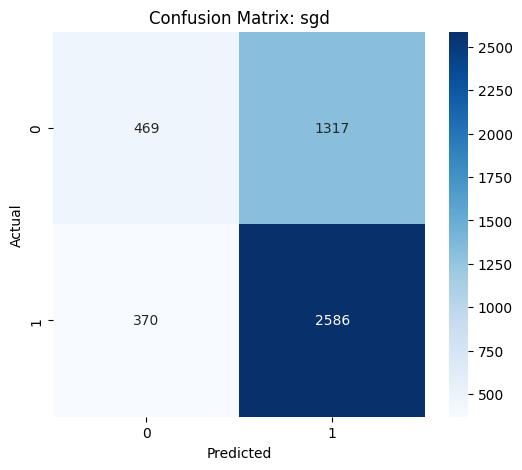


=== Training svm_rbf ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [24]:
# train all models
# model_dict={'sgd': models['sgd'], 'logistic': models['logistic']}
results = train_and_evaluate(X_train, y_train_enc, X_test, y_test_enc, models)


In [ ]:
y_train_enc

array([1, 1, 1, ..., 1, 1, 1])

In [17]:
# Top 3 models by ROC AUC
top_models = summary_df.sort_values(by='ROC AUC', ascending=False).head(3)
print(top_models)


           Model  Accuracy  Balanced Accuracy  Log Loss   ROC AUC  F1 Weighted
6       svm_poly  0.843555           0.782152  0.347566  0.935105     0.845985
5        svm_rbf  0.841996           0.768233  0.356540  0.934509     0.844082
4  logistic_saga  0.870062           0.757526  0.354306  0.934403     0.863523


In [32]:
top_models

,Model,Accuracy,Balanced Accuracy,Log Loss,ROC AUC,F1 Weighted
6,svm_poly,0.843555,0.782152,0.347566,0.935105,0.845985
5,svm_rbf,0.841996,0.768233,0.356540,0.934509,0.844082
4,logistic_saga,0.870062,0.757526,0.354306,0.934403,0.863523
